# Detección de discurso de odio en español con BERT: fine-tuning progresivo, explicabilidad y prueba de sesgo

Grupo: Julián Espinosa, Jhon Jairo Cuervo y David Crespo.

## El problema

La moderación de contenido en redes sociales tiene que decidir, para cada mensaje, si contiene discurso de odio o lenguaje tóxico. Una lista de palabras prohibidas falla de dos formas distintas: por un lado dispara falsos positivos, porque mencionar una identidad o un grupo (mujer trans, musulmán, venezolano) no es lo mismo que atacarlo, y un filtro basado en palabras clave tiende a marcar como tóxico cualquier mensaje que solo *mencione* esos términos, sin importar el contexto; por otro lado, deja pasar ataques reales que no usan ninguna palabra de la lista, porque el odio también se expresa con sarcasmo, comparaciones o insinuaciones. En ambos casos el problema de fondo es el mismo: el significado depende del contexto de toda la oración, no de palabras sueltas.

Esto hace que este caso sea un buen banco de pruebas para BERT. A diferencia de un modelo de bolsa de palabras, BERT construye una representación de cada palabra que depende de las palabras que la rodean en ambas direcciones, así que en principio debería distinguir mejor entre "mencionar" y "atacar". Además, los datasets etiquetados de discurso de odio son costosos de construir (hay que anotar manualmente miles de mensajes, muchas veces con más de un anotador por mensaje para tener acuerdo), así que suelen ser más chicos que un dataset de noticias o de reseñas. Ese es justamente el escenario donde partir de un modelo preentrenado como BETO, en vez de entrenar un Transformer desde cero, tiene más sentido: la mayor parte del conocimiento del idioma ya viene incorporado, y solo hace falta especializarlo con relativamente pocos ejemplos etiquetados.

## Qué cambia respecto al notebook guía

- **Dominio y datos:** en vez de clasificación temática de noticias (`MarcOrfilaCarreras/spanish-news`), abordamos **detección de discurso de odio o toxicidad en comentarios en español** (`textdetox/multilingual_toxicity_dataset`, configuración `es`, texto real de redes sociales etiquetado como tóxico o no tóxico).
- **Fine-tuning progresivo:** la guía solo prueba dos extremos, congelar todo el modelo base o liberar todas las capas. Nosotros agregamos un punto intermedio: descongelar únicamente las últimas capas del encoder de BERT, para ver qué tanto se gana (o se pierde) frente a los dos extremos, y a qué costo en tiempo de entrenamiento.
- **Explicabilidad:** para el mejor modelo, implementamos una técnica de oclusión de palabras (quitar una palabra a la vez y medir cuánto cambia la probabilidad de que el texto se clasifique como tóxico) para ver en qué palabras se apoya cada predicción. Esta técnica no se vio en clase.
- **Prueba de sesgo:** evaluamos el modelo con un conjunto de frases neutrales que mencionan distintos grupos e identidades (género, orientación sexual, religión, nacionalidad, discapacidad) en contextos cotidianos y positivos, para revisar si el modelo las marca como tóxicas solo por mencionar esos grupos, un problema documentado en varios clasificadores de discurso de odio.
- **Demo interactivo:** una función para escribir cualquier frase y ver la predicción del modelo junto con las palabras que más influyeron en ella.

## Aviso sobre el contenido

Como este es un dataset real de detección de discurso de odio, algunos de los ejemplos que se muestran en el análisis exploratorio contienen lenguaje ofensivo real, tal como fue recolectado y etiquetado por los autores del dataset para investigación en moderación de contenido. No es contenido que nosotros hayamos generado; lo mostramos únicamente con fines de análisis, igual que lo haría cualquier paper o dataset académico sobre este tema.


## 0. Preparación del entorno

In [ ]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Corriendo en Colab: {IN_COLAB}")


Corriendo en Colab: True


In [ ]:
!pip install -q -U transformers datasets accelerate evaluate scikit-learn wordcloud seaborn torchinfo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.5 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")


Dispositivo: cpu


Dejamos configurado desde el inicio un modo más liviano para cuando no hay GPU: menos épocas, secuencias más cortas y, si hace falta, un límite al tamaño del conjunto de entrenamiento y de validación/prueba. El resto de decisiones (longitud máxima de secuencia) las tomamos con base en el EDA.

**Nota sobre esta configuración:** la primera versión de este notebook usaba una muestra de entrenamiento más grande (3500 textos) y 2 épocas por variante. Al ejecutarlo en Colab sin GPU, entrenar las tres variantes (congelado, parcial, completo) resultó demasiado lento para ser práctico.

In [ ]:
CONFIG = {
    'model_ckpt': 'dccuchile/bert-base-spanish-wwm-cased',
    'num_epochs': 3 if DEVICE.type == 'cuda' else 1,
    'batch_size': 16 if DEVICE.type == 'cuda' else 8,
    'max_train_size': None if DEVICE.type == 'cuda' else 900,
    'max_eval_size': None if DEVICE.type == 'cuda' else 300,
    'max_len_cap': 128 if DEVICE.type == 'cuda' else 64,
    'num_unfrozen_layers_partial': 2,
}
print(CONFIG)


{'model_ckpt': 'dccuchile/bert-base-spanish-wwm-cased', 'num_epochs': 1, 'batch_size': 8, 'max_train_size': 900, 'max_eval_size': 300, 'max_len_cap': 64, 'num_unfrozen_layers_partial': 2}


## 1. Cargando el dataset

Usamos [`textdetox/multilingual_toxicity_dataset`](https://huggingface.co/datasets/textdetox/multilingual_toxicity_dataset). Es una compilación de datasets de toxicidad en 15 idiomas, donde cada idioma se guarda como un split distinto dentro de una única configuración (`default`), y no como configuraciones separadas. Por eso cargamos el dataset completo y luego seleccionamos el split en español (`es`). Cada fila trae un texto corto (tipo publicación de red social) y una etiqueta binaria: 1 si el texto es tóxico, 0 si no lo es. Es un dataset público, sin necesidad de pedir acceso ni autenticarse con un token de Hugging Face.

In [ ]:
from datasets import load_dataset

DATASET_NAME = "textdetox/multilingual_toxicity_dataset"
LANGUAGE_SPLIT = "es"

raw_datasets = load_dataset(DATASET_NAME)
print(raw_datasets)

raw_dataset = raw_datasets[LANGUAGE_SPLIT]
print(f"Usando el idioma: {LANGUAGE_SPLIT} ({len(raw_dataset)} ejemplos)")


README.md:   0%|          | 0.00/8.91k [00:00<?, ?B/s]

data/en-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  267kB            

data/en-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/ru-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  388kB            

data/ru-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating he split:   0%|          | 0/2011 [00:00<?, ? examples/s]

Generating hin split:   0%|          | 0/4363 [00:00<?, ? examples/s]

Generating tt split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating ja split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    en: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    ru: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    uk: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    de: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    es: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    am: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    zh: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    ar: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    hi: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    it: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    fr: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    he: Dataset({
        features: ['text', 'toxic

In [ ]:
print(raw_dataset.column_names)
raw_dataset[0]


['text', 'toxic']


{'text': 'A este tambien lo habia que echar porque era una puta mierda, como Cumic',
 'toxic': 1}

## 2. Análisis exploratorio (EDA)

In [ ]:
import pandas as pd

df = raw_dataset.to_pandas()
df = df[['text', 'toxic']].copy()
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 0].drop_duplicates(subset='text').reset_index(drop=True)

print(f"Total de textos (tras quitar vacíos y duplicados): {len(df)}")
df.head()


Total de textos (tras quitar vacíos y duplicados): 5000


,text,toxic
0,A este tambien lo habia que echar porque era u...,1
1,la mañana coincidió que charlando de mis labio...,1
2,El vídeo del que todo el mundo habla XD « Jord...,1
3,del peor error de mexico queda claro que fue u...,1
4,antes de irme a trabajar la abuela me folla,1


### Balance de clases

Este es nuestro objetivo de clasificación: 1 es tóxico, 0 no lo es.

toxic
0    2500
1    2500
Name: count, dtype: int64


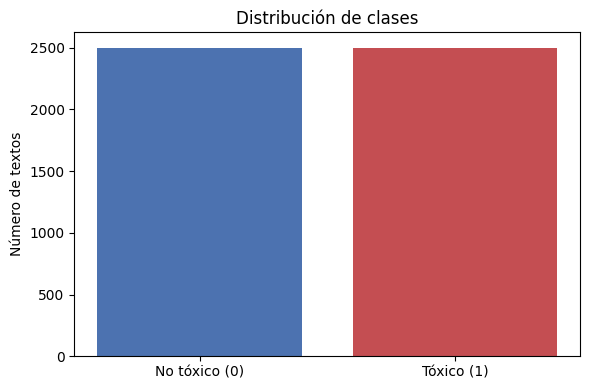

Razón entre la clase mayoritaria y la minoritaria: 1.00x


In [ ]:
import matplotlib.pyplot as plt

toxic_counts = df['toxic'].value_counts().sort_index()
print(toxic_counts)

plt.figure(figsize=(6, 4))
plt.bar(['No tóxico (0)', 'Tóxico (1)'], toxic_counts.values, color=['#4C72B0', '#C44E52'])
plt.title('Distribución de clases')
plt.ylabel('Número de textos')
plt.tight_layout()
plt.show()

ratio_desbalance = toxic_counts.max() / toxic_counts.min()
print(f"Razón entre la clase mayoritaria y la minoritaria: {ratio_desbalance:.2f}x")


### Longitud de los textos

         num_chars  num_words
count  5000.000000  5000.0000
mean    180.466800    31.5860
std     110.860534    19.2627
min      15.000000     3.0000
25%     106.000000    19.0000
50%     153.000000    27.0000
75%     229.000000    40.0000
max    1049.000000   187.0000


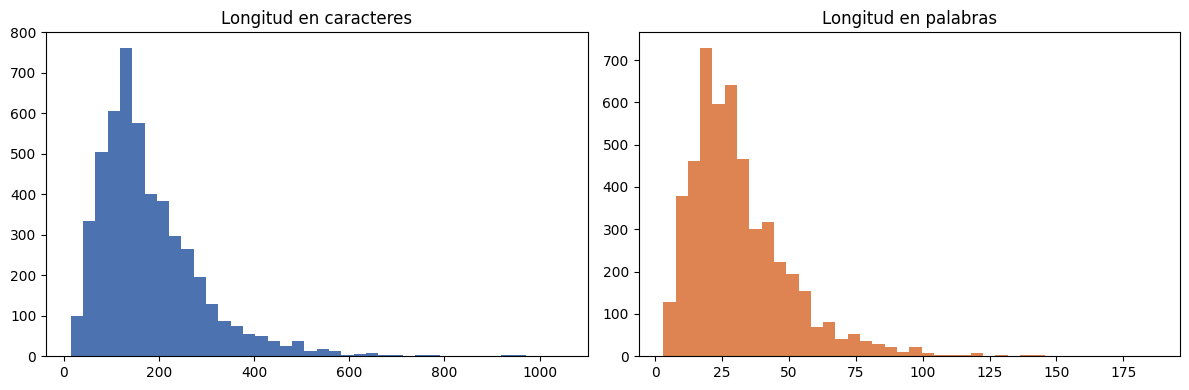

Percentil 95 de longitud en palabras: 68


In [ ]:
df['num_chars'] = df['text'].str.len()
df['num_words'] = df['text'].str.split().apply(len)

print(df[['num_chars', 'num_words']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['num_chars'], bins=40, color='#4C72B0')
axes[0].set_title('Longitud en caracteres')
axes[1].hist(df['num_words'], bins=40, color='#DD8452')
axes[1].set_title('Longitud en palabras')
plt.tight_layout()
plt.show()

p95_words = int(np.percentile(df['num_words'], 95))
print(f"Percentil 95 de longitud en palabras: {p95_words}")


In [ ]:
CONFIG['max_len'] = int(np.clip(p95_words + 8, 32, CONFIG['max_len_cap']))
print(f"max_len elegido (data-driven, con margen sobre el percentil 95, tope de {CONFIG['max_len_cap']} en modo CPU): {CONFIG['max_len']}")


max_len elegido (data-driven, con margen sobre el percentil 95, tope de 64 en modo CPU): 64


### Ejemplos de cada clase

Como se explicó al inicio, algunos de estos ejemplos reales contienen lenguaje ofensivo, propio de la naturaleza del dataset.

In [ ]:
print("--- Ejemplos NO tóxicos ---")
for texto in df[df['toxic'] == 0]['text'].sample(3, random_state=SEED):
    print(f"- {texto}")

print()
print("--- Ejemplos TÓXICOS ---")
for texto in df[df['toxic'] == 1]['text'].sample(3, random_state=SEED):
    print(f"- {texto}")


--- Ejemplos NO tóxicos ---
- El chilote es muy creyente, tiene mucha fe en sus santos, en sus brujos y en sus leyendas, como la del Trauco, la Pincoya o el Caleuche
- Advertidos quedan, tengan cuidado con él, es muy inteligente y sabe hablar chino.
- Zara es un orgullo español.

--- Ejemplos TÓXICOS ---
- La otra opción sería que Ciudadanos plantease la moción de censura y le diese el gobierno al Partido Popular o incluso a él mismo, pero Juan Marín es un 'pagafanta', al que han timado, no se entera de nada o sí se entera pero le da igual, lo cual sería más grave y es una clara muleta haciéndose participe del 'chiringuito'
- Anda a lavarte el hoyo sucio ctm, te crees mejor que los demás pero eres un ignorante qliao que ni siquiera terminó el colegio, facho ctm
- No confíes en el gabacho, que es muy astuto y puede hacerte engaños, mejor hagas tratos con los de aquí, que son de confianza.


### Nubes de palabras por clase

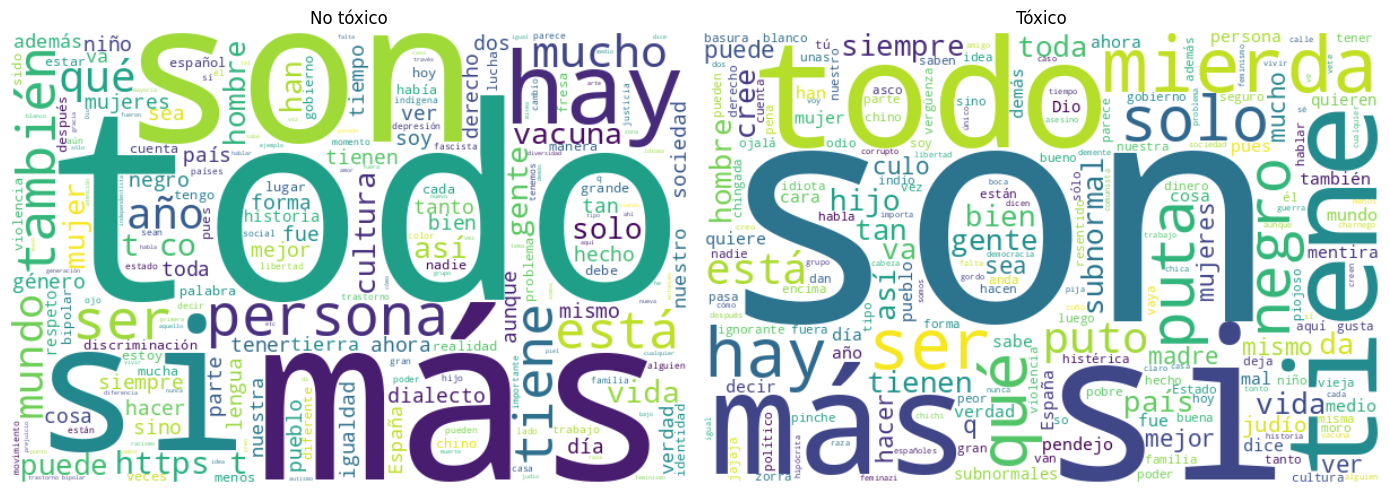

In [ ]:
from wordcloud import WordCloud

stopwords_texto = (
    "a al algo algunas algunos ante antes como con contra cual cuando de del desde donde "
    "durante e el ella ellas ellos en entre era erais eramos eran eras eres es esa esas ese eso esos esta estas "
    "este esto estos ha hace hacia hasta la las le les lo los mas me mi mientras muy nada ni no nos nosotras "
    "nosotros o os otra otras otro otros para pero poco por porque que quien quienes se sin sobre su sus te tu "
    "tus un una uno unos y ya yo mis del al que rt"
)
STOPWORDS_ES = set(stopwords_texto.split())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, clase, titulo in zip(axes, [0, 1], ['No tóxico', 'Tóxico']):
    texto = ' '.join(df[df['toxic'] == clase]['text'].tolist())
    wc = WordCloud(width=600, height=400, background_color='white', stopwords=STOPWORDS_ES).generate(texto)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(titulo)
    ax.axis('off')
plt.tight_layout()
plt.show()


### Análisis del EDA

**Balance de clases.** El split en español está perfectamente balanceado: 2500 textos tóxicos y 2500 no tóxicos (razón 1,00). Es un dataset curado a propósito, no una muestra natural de redes sociales, donde la proporción de mensajes tóxicos es mucho menor. Esto tiene dos consecuencias: accuracy y F1 van a contar prácticamente la misma historia (en nuestro subconjunto de prueba la proporción es 156/144), y el modelo aprende con una prevalencia de 50 % que no corresponde a la realidad. En producción habría muchos más mensajes no tóxicos y la precisión sobre la clase tóxica sería menor que la que medimos aquí.

**Longitud.** Los textos son cortos, típicos de publicaciones y comentarios: mediana de 27 palabras (153 caracteres), 75 % por debajo de 40 palabras y percentil 95 en 68 palabras, con una cola larga de hasta 187. Como el tokenizador WordPiece de BETO parte algunas palabras en varios sub-tokens y además cuenta la puntuación, un texto de *n* palabras produce más de *n* tokens. Con el tope de 64 tokens del modo CPU, los textos más largos (aproximadamente el cuarto superior) probablemente se truncan. Si la parte ofensiva está al final del mensaje, el modelo simplemente no la ve. Retomamos este punto en el análisis de errores y en la explicabilidad.

**Vocabulario.** Las dos nubes están dominadas por palabras funcionales que nuestra lista de stopwords no cubría ("son", "todo", "más", "si", "hay", "ser", "qué"; varias con tilde, que la lista tenía sin tilde). Eso ya dice algo: buena parte del texto es igual en ambas clases. Aun así se ven diferencias claras:

- En la clase tóxica aparecen insultos explícitos (*mierda, puta, puto, subnormal, pendejo, idiota, basura, asco, zorra*) y también insultos regionales (*chingada, pinche* de México; *ctm, qliao* de Chile, visibles en los ejemplos). El dataset mezcla variedades del español, lo que obliga al modelo a cubrir vocabulario ofensivo muy distinto.
- En la clase no tóxica aparecen términos de discusión social: *cultura, derecho, igualdad, género, discriminación, lengua, dialecto, sociedad, respeto*.
- El hallazgo más importante es el solapamiento en términos de identidad: *mujer/mujeres, hombre, negro, chino, España, indígena/indio* aparecen en las dos nubes, y *negro* y *judío* son especialmente visibles en la tóxica. Es exactamente el problema planteado en la introducción: la mención de un grupo aparece tanto en textos que lo atacan como en textos que lo defienden o simplemente lo nombran. Un filtro de palabras clave fallaría aquí, y es la razón para probar un modelo contextual como BERT y para hacer la prueba de sesgo de la sección 10.

## 3. Tokenizador

Usamos el mismo tokenizador preentrenado de BETO que usa la guía, en vez de entrenar uno propio: la ventaja de partir de un modelo preentrenado es justamente no tener que reconstruir esa parte desde cero.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_ckpt'])
print(f"Tamaño del vocabulario: {tokenizer.vocab_size}")
print(f"Longitud máxima soportada por el modelo: {tokenizer.model_max_length}")


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Tamaño del vocabulario: 31002
Longitud máxima soportada por el modelo: 512


In [ ]:
ejemplo = df['text'].iloc[0]
tokens = tokenizer(ejemplo, max_length=CONFIG['max_len'], truncation=True, padding='max_length')
print(ejemplo)
print(tokens['input_ids'][:20])
print(tokenizer.convert_ids_to_tokens(tokens['input_ids'])[:20])


A este tambien lo habia que echar porque era una puta mierda, como Cumic
[4, 1070, 1365, 12840, 1114, 19021, 1038, 8452, 1817, 1538, 1108, 5016, 3383, 1017, 1184, 1488, 1155, 30941, 5, 1]
['[CLS]', 'A', 'este', 'tambien', 'lo', 'habia', 'que', 'echar', 'porque', 'era', 'una', 'puta', 'mierda', ',', 'como', 'Cu', '##mi', '##c', '[SEP]', '[PAD]']


## 4. Preparando los splits

El dataset viene en un único split, así que hacemos nuestra propia partición entrenamiento / validación / prueba (80 / 10 / 10).

In [ ]:
from datasets import Dataset, DatasetDict

hf_dataset = Dataset.from_pandas(df[['text', 'toxic']].rename(columns={'toxic': 'label'}), preserve_index=False)

split_1 = hf_dataset.train_test_split(train_size=0.8, seed=SEED)
split_2 = split_1['test'].train_test_split(train_size=0.5, seed=SEED)

dataset_splits = DatasetDict({
    'train': split_1['train'],
    'val': split_2['train'],
    'test': split_2['test'],
})

if CONFIG['max_train_size'] is not None and len(dataset_splits['train']) > CONFIG['max_train_size']:
    dataset_splits['train'] = dataset_splits['train'].shuffle(seed=SEED).select(range(CONFIG['max_train_size']))
    print(f"Modo CPU: usando un subconjunto de {CONFIG['max_train_size']} textos de entrenamiento")

if CONFIG['max_eval_size'] is not None:
    for split in ('val', 'test'):
        if len(dataset_splits[split]) > CONFIG['max_eval_size']:
            dataset_splits[split] = dataset_splits[split].shuffle(seed=SEED).select(range(CONFIG['max_eval_size']))
    print(f"Modo CPU: usando un subconjunto de hasta {CONFIG['max_eval_size']} textos para validación y prueba")

print(dataset_splits)


Modo CPU: usando un subconjunto de 900 textos de entrenamiento
Modo CPU: usando un subconjunto de hasta 300 textos para validación y prueba
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 900
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 300
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 300
    })
})


In [ ]:
def preprocess_function(examples):
    return tokenizer(examples['text'], max_length=CONFIG['max_len'], truncation=True, padding='max_length')

tokenized_dataset = dataset_splits.map(preprocess_function, batched=True)
tokenized_dataset


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 900
    })
    val: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 300
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 300
    })
})

## 5. Métricas y control de qué capas se entrenan

Usamos `evaluate` para calcular la exactitud. Como estamos en un problema binario y no sabemos de antemano qué tan desbalanceado está, agregamos también F1, que castiga más a un modelo que solo acierta prediciendo siempre la clase mayoritaria.

In [ ]:
import evaluate
from typing import Dict, Any

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(pred) -> Dict[str, Any]:
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels)
    return {**acc, **f1}


La guía solo prueba dos extremos: todo el modelo base congelado, o todas las capas libres. Nosotros definimos una función que permite descongelar exactamente las últimas N capas del encoder de BERT, para poder probar un punto intermedio.

In [ ]:
def configurar_capas_entrenables(model, num_capas_entrenables=None):
    # num_capas_entrenables=None significa "liberar todo el modelo base" (fine-tuning completo).
    # num_capas_entrenables=0 significa "modelo base totalmente congelado".
    # Cualquier otro número libera esa cantidad de capas del encoder, contando desde el final.
    for param in model.base_model.parameters():
        param.requires_grad = (num_capas_entrenables is None)

    if num_capas_entrenables is not None and num_capas_entrenables > 0:
        capas_encoder = model.base_model.encoder.layer
        for capa in capas_encoder[-num_capas_entrenables:]:
            for param in capa.parameters():
                param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    total = sum(p.numel() for p in model.parameters())
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parámetros totales: {total:,} | Parámetros entrenables: {entrenables:,} ({100 * entrenables / total:.1f}%)")
    return model


## 6. Entrenamiento: congelado, parcial y completo

Definimos una función que entrena una variante completa (construye el modelo, configura qué capas se entrenan, entrena y evalúa en el conjunto de prueba) para no repetir el mismo código tres veces.

In [ ]:
import inspect
from transformers import TrainingArguments

def construir_training_args(output_dir):
    kwargs = dict(
        output_dir=output_dir,
        num_train_epochs=CONFIG['num_epochs'],
        learning_rate=2e-5,
        per_device_train_batch_size=CONFIG['batch_size'],
        per_device_eval_batch_size=CONFIG['batch_size'],
        weight_decay=0.01,
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        disable_tqdm=False,
        logging_steps=50,
    )
    # Entre versiones de transformers cambió el nombre de este parámetro; lo detectamos
    # para que el notebook funcione igual con la versión que traiga instalada Colab.
    firma = inspect.signature(TrainingArguments.__init__)
    if 'eval_strategy' in firma.parameters:
        kwargs['eval_strategy'] = 'epoch'
    else:
        kwargs['evaluation_strategy'] = 'epoch'
    return TrainingArguments(**kwargs)


In [ ]:
import time
from transformers import AutoModelForSequenceClassification, Trainer

ID2LABEL = {0: 'no_toxico', 1: 'toxico'}

def entrenar_variante(nombre, num_capas_entrenables, output_dir):
    print(f"\n=== Entrenando: {nombre} ===")
    model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG['model_ckpt'], num_labels=2
    ).to(DEVICE)
    model = configurar_capas_entrenables(model, num_capas_entrenables)

    training_args = construir_training_args(output_dir)
    trainer_kwargs = dict(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        train_dataset=tokenized_dataset['train'],
        eval_dataset=tokenized_dataset['val'],
    )
    # En versiones recientes de transformers el argumento 'tokenizer' de Trainer
    # fue reemplazado por 'processing_class'; detectamos cuál existe para que
    # el notebook funcione igual sin importar la versión instalada en Colab.
    firma_trainer = inspect.signature(Trainer.__init__)
    if 'processing_class' in firma_trainer.parameters:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer
    trainer = Trainer(**trainer_kwargs)

    inicio = time.time()
    trainer.train()
    tiempo_entrenamiento = time.time() - inicio

    model.eval()
    metricas_test = trainer.evaluate(tokenized_dataset['test'])

    total = sum(p.numel() for p in model.parameters())
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"[{nombre}] tiempo de entrenamiento: {tiempo_entrenamiento:.1f}s | "
          f"accuracy test: {metricas_test['eval_accuracy']:.4f} | f1 test: {metricas_test['eval_f1']:.4f}")

    return {
        'nombre': nombre,
        'model': model,
        'trainer': trainer,
        'tiempo_entrenamiento': tiempo_entrenamiento,
        'parametros_totales': total,
        'parametros_entrenables': entrenables,
        'accuracy': metricas_test['eval_accuracy'],
        'f1': metricas_test['eval_f1'],
    }


In [ ]:
variantes = [
    ('Congelado (solo clasificador)', 0, './hf_congelado'),
    (f"Descongelando las últimas {CONFIG['num_unfrozen_layers_partial']} capas", CONFIG['num_unfrozen_layers_partial'], './hf_parcial'),
    ('Fine-tuning completo', None, './hf_completo'),
]

resultados = {}
for nombre, num_capas, output_dir in variantes:
    resultados[nombre] = entrenar_variante(nombre, num_capas, output_dir)



=== Entrenando: Congelado (solo clasificador) ===


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Parámetros totales: 109,852,418 | Parámetros entrenables: 109,852,418 (100.0%)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.349032,0.364789,0.856667,0.859935


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.349032,0.324910,1,0.856667,0.846975


[Fine-tuning completo] tiempo de entrenamiento: 668.2s | accuracy test: 0.8567 | f1 test: 0.8470


### Análisis de los tiempos de entrenamiento

| Variante | Parámetros entrenables | Tiempo |
|---|---|---|
| Congelado (solo clasificador) | 1.538 (0,001 %) | 273 s |
| Últimas 2 capas | 14,2 M (12,9 %) | 321 s |
| Fine-tuning completo | 109,9 M (100 %) | 668 s |

El completo fue el más lento y el congelado el más rápido, pero la diferencia no es proporcional a la cantidad de parámetros entrenables. Pasar de 1.538 a 14 millones de parámetros (unas 9000 veces más) solo aumentó el tiempo en un 17 %. Pasar de 14 a 110 millones (7,7 veces más) lo multiplicó por 2,1.

La explicación está en qué se paga en cada paso de entrenamiento:

1. El forward pass siempre recorre las 12 capas del encoder, incluso con el modelo base congelado: para calcular la salida del clasificador hay que calcular primero la representación de BERT. Este costo es fijo y es la mayor parte del tiempo de la variante congelada.
2. El backward pass y la actualización de pesos sí dependen de lo que se entrena: con el modelo congelado el gradiente se detiene en el clasificador; con 2 capas libres se propaga solo por ellas; con el completo recorre las 12 capas y el optimizador (AdamW) mantiene dos estados adicionales por cada uno de los 110 M de parámetros.
3. Hay un costo fijo adicional: la evaluación sobre validación al final de la época (unos 55 s en el log) va incluida en el tiempo medido para las tres variantes.

Por eso la variante parcial obtiene gran parte del beneficio de entrenar el encoder por un costo marginal pequeño. Otra observación importante para la decisión de producción: en inferencia las tres variantes cuestan exactamente lo mismo, porque la arquitectura y el forward pass son idénticos. La diferencia de costo existe solo durante el entrenamiento.

### Intento inicial descartado por costo computacional

La primera versión de este notebook buscaba una comparación más robusta: más datos de entrenamiento y más épocas por variante. Al ejecutarla en Colab sin GPU, la celda de entrenamiento llevaba 41 minutos corriendo sin haber terminado y decidimos cancelarla:

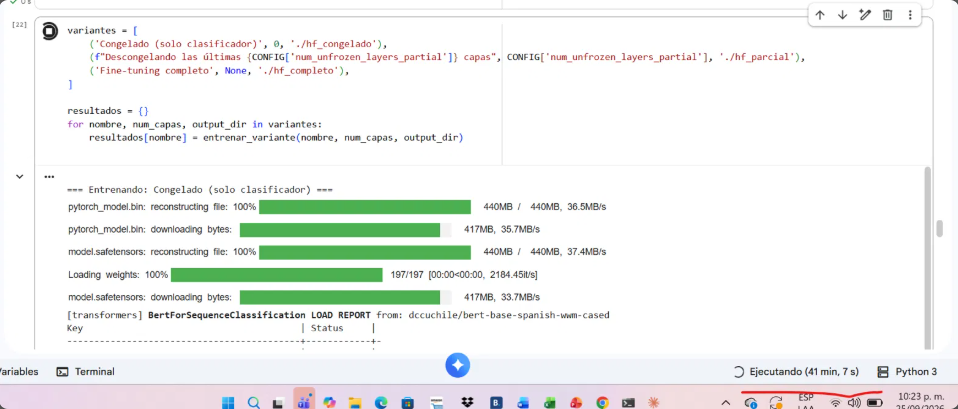

| | Versión inicial (descartada) | Versión final |
|---|---|---|
| Textos de entrenamiento | 3500 | 900 |
| Épocas por variante | 2 | 1 |
| Ejemplos procesados por variante | 7000 | 900 |
| Longitud máxima de secuencia | mayor que 64 | 64 |
| Tiempo de entrenamiento (3 variantes) | cancelada a los 41 min | ≈ 21 min (1262 s) |

Con los tiempos reales de la versión final podemos estimar cuánto habría tardado la inicial. El costo de entrenamiento crece aproximadamente de forma lineal con el número de ejemplos procesados (textos × épocas), que en la versión inicial era unas 7,8 veces mayor. Eso da del orden de 2 horas y 45 minutos solo de entrenamiento, y más aún con secuencias más largas, porque el costo de la atención crece con la longitud. Además, en Colab gratuito la sesión se desconecta por inactividad o por límite de tiempo, así que una ejecución de casi tres horas tenía un riesgo real de perderse a mitad de camino.

La decisión fue reducir de forma deliberada la muestra, las épocas y la longitud máxima. Eso tiene un costo que discutimos en las conclusiones: con 900 textos y una sola época, los modelos quedan sub-entrenados y las métricas son una cota inferior de lo que BERT puede lograr en este problema. Aun así, la comparación relativa entre las tres variantes, que es el objetivo del experimento, se mantiene, y el episodio en sí ilustra una limitación práctica del fine-tuning de modelos tipo BERT sin GPU.

## 7. Comparación de las tres variantes

                            variante  accuracy        f1  \
0               Fine-tuning completo  0.856667  0.846975   
1  Descongelando las últimas 2 capas  0.780000  0.789809   
2      Congelado (solo clasificador)  0.520000  0.052632   

   tiempo_entrenamiento_seg  parametros_entrenables  porcentaje_entrenable  
0                668.228721               109852418             100.000000  
1                320.745761                14177282              12.905753  
2                273.228367                    1538               0.001400  


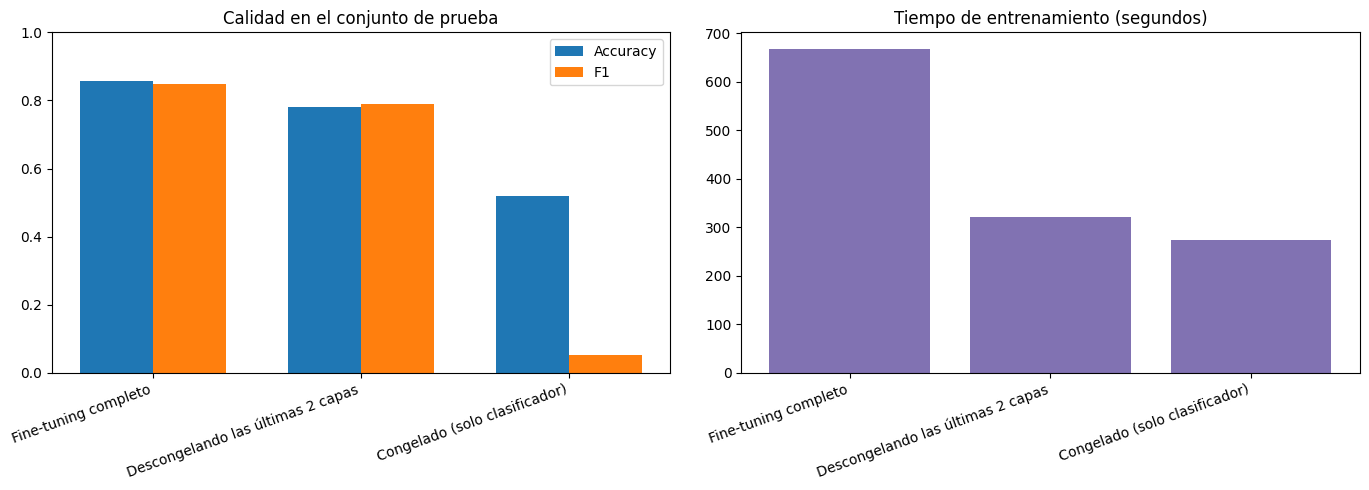


Mejor variante por F1: Fine-tuning completo


In [ ]:
comparacion = pd.DataFrame([
    {
        'variante': r['nombre'],
        'accuracy': r['accuracy'],
        'f1': r['f1'],
        'tiempo_entrenamiento_seg': r['tiempo_entrenamiento'],
        'parametros_entrenables': r['parametros_entrenables'],
        'porcentaje_entrenable': 100 * r['parametros_entrenables'] / r['parametros_totales'],
    }
    for r in resultados.values()
])
comparacion = comparacion.sort_values('f1', ascending=False).reset_index(drop=True)
print(comparacion)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(comparacion))
width = 0.35
axes[0].bar(x_pos - width/2, comparacion['accuracy'], width, label='Accuracy')
axes[0].bar(x_pos + width/2, comparacion['f1'], width, label='F1')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparacion['variante'], rotation=20, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].set_title('Calidad en el conjunto de prueba')

axes[1].bar(comparacion['variante'], comparacion['tiempo_entrenamiento_seg'], color='#8172B2')
axes[1].set_xticklabels(comparacion['variante'], rotation=20, ha='right')
axes[1].set_title('Tiempo de entrenamiento (segundos)')

plt.tight_layout()
plt.show()

mejor_nombre = comparacion.iloc[0]['variante']
mejor_modelo = resultados[mejor_nombre]['model']
print(f"\nMejor variante por F1: {mejor_nombre}")


### Análisis de la comparación

**De congelado a parcial** el salto es enorme: la accuracy pasa de 0,520 a 0,780 (+26 puntos) y el F1 de 0,053 a 0,790, con solo un 17 % más de tiempo.

Sin embargo, hay que leer con cuidado el resultado del modelo congelado. Un F1 de 0,05 significa que casi nunca predice la clase tóxica: su accuracy en prueba (0,520) coincide con la proporción de textos no tóxicos en ese conjunto (156/300 = 0,52), y su pérdida de entrenamiento (0,700) está prácticamente en ln 2 ≈ 0,693, que es la pérdida de un clasificador que no aprendió nada. La causa más probable no es que las representaciones de BERT congelado sean inútiles, sino nuestra configuración: usamos el mismo learning rate (2e-5) para las tres variantes. Ese valor es el recomendado para ajustar un modelo preentrenado completo, pero es demasiado bajo para entrenar desde cero una capa lineal de 1.538 parámetros en solo 113 pasos; para esa variante lo usual sería un learning rate del orden de 1e-3. Es decir, nuestra comparación subestima a la variante congelada, y lo reportamos como limitación del experimento.

**De parcial a completo** la ganancia es menor pero sustancial: la accuracy sube de 0,780 a 0,857 (+7,7 puntos) y el F1 de 0,790 a 0,847, a cambio de 2,1 veces más tiempo (de 321 s a 668 s). Dicho de otra forma, la tasa de error baja de 22,0 % a 14,3 %: el modelo completo comete 35 % menos errores. La pérdida de entrenamiento también lo refleja (0,56 contra 0,35).

**¿Cuál elegiríamos para producción sin GPU?** El fine-tuning completo. El argumento clave es el de la sección anterior: la diferencia de costo está solo en el entrenamiento, que se hace una vez (y puede hacerse en una GPU prestada, por ejemplo en Colab), mientras que en inferencia las tres variantes tienen exactamente el mismo costo por mensaje. Pagar 6 minutos más una sola vez para cometer un 35 % menos de errores durante toda la vida del modelo vale la pena. La variante parcial tendría sentido si el modelo hubiera que re-entrenarlo con mucha frecuencia (por ejemplo, para adaptarse a nuevas jergas) o si la memoria para entrenar fuera la restricción, ya que no necesita guardar gradientes ni estados del optimizador para las 10 capas congeladas.

## 8. Matriz de confusión y análisis de errores del mejor modelo

              precision    recall  f1-score   support

   no_toxico       0.85      0.88      0.87       156
      toxico       0.87      0.83      0.85       144

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300



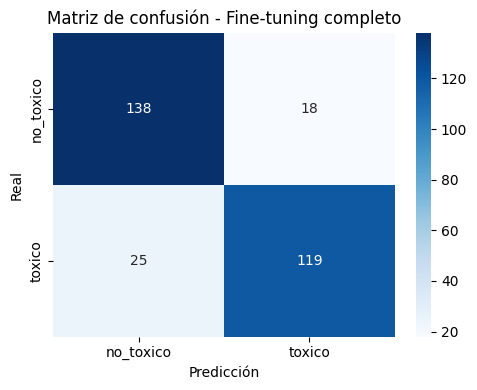

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

mejor_trainer = resultados[mejor_nombre]['trainer']
predicciones = mejor_trainer.predict(tokenized_dataset['test'])
y_true = predicciones.label_ids
y_pred = predicciones.predictions.argmax(-1)

print(classification_report(y_true, y_pred, target_names=['no_toxico', 'toxico']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no_toxico', 'toxico'], yticklabels=['no_toxico', 'toxico'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de confusión - {mejor_nombre}')
plt.tight_layout()
plt.show()


In [ ]:
test_df = pd.DataFrame({
    'texto': tokenized_dataset['test']['text'],
    'real': y_true,
    'prediccion': y_pred,
})
errores_df = test_df[test_df['real'] != test_df['prediccion']]
print(f"Total de errores: {len(errores_df)} de {len(test_df)} ({100 * len(errores_df) / len(test_df):.1f}%)")
errores_df.sample(min(10, len(errores_df)), random_state=SEED)


Total de errores: 43 de 300 (14.3%)


,texto,real,prediccion
274,Quien fue el subnormal en poner un botón para ...,0,1
192,"Ciudadanos, el partido más traidor y ladino de...",1,0
201,Menusmal que pa esu estamus paki unus cuantus ...,0,1
272,Entonces cuando te pones ese outfit y te miras...,0,1
270,"El fascismo no existe sin el comunismo, el com...",1,0
277,Kasandra era una estudiante de 17 años que soñ...,1,0
31,"Pues bien, tenemos a Tree que es una guapa y r...",0,1
70,Las costas canarias están a merced de que veng...,1,0
56,"Y el guardia grita- !!demente, demente!!! y el...",0,1
13,@kelokemanin Yo le llamo escalera real porque ...,0,1


### Análisis de errores

La matriz de confusión del fine-tuning completo muestra 43 errores sobre 300 textos: 25 falsos negativos (textos tóxicos que el modelo deja pasar) y 18 falsos positivos (textos no tóxicos marcados como tóxicos). El modelo es algo más preciso (precisión de 0,87 en la clase tóxica) que exhaustivo (recall de 0,83).

Nota: en la muestra aleatoria de 10 errores de arriba predominan los falsos positivos (6 contra 4), pero una muestra de 10 no es representativa; la matriz completa es la referencia.

Los errores de la muestra tienen patrones reconocibles:

- **Falsos positivos por palabra gatillo.** "Quien fue el *subnormal* en poner un botón…" o el relato donde el guardia grita "¡demente, demente!" contienen términos ofensivos, pero en un contexto de queja cotidiana o de narración. El primero es incluso discutible como etiqueta: es un insulto, aunque no dirigido a nadie en particular. Aquí el modelo se comporta parcialmente como un filtro de palabras clave, justo el tipo de error que esperábamos que BERT redujera.
- **Falsos positivos por ortografía no estándar.** "Menusmal que pa esu estamus paki unus cuantus…" está escrito imitando un habla coloquial. Es texto poco frecuente en el preentrenamiento de BETO, que se fragmenta en sub-tokens raros, y el modelo lo asocia con la clase tóxica.
- **Falsos negativos por toxicidad implícita.** "Ciudadanos, el partido más traidor y ladino…", "El fascismo no existe sin el comunismo…" y "Las costas canarias están a merced de que venga…" no usan groserías: el ataque o la carga xenófoba está en la afirmación, no en una palabra. Es la segunda falla de los filtros de palabras clave que describimos en la introducción, y nuestro modelo, entrenado con pocos datos, todavía la comete.
- **Posible efecto del truncamiento.** Algunos falsos negativos son textos largos de tipo narrativo (por ejemplo el que empieza "Kasandra era una estudiante de 17 años…"). Con un tope de 64 tokens, si la parte ofensiva está al final, el modelo nunca la llega a ver.

**¿Qué error es más grave?** Depende de cómo se use el sistema. Si el modelo borra mensajes automáticamente, los falsos positivos son más graves: censuran discurso legítimo y, como muestra la prueba de sesgo, tienden a afectar precisamente a las comunidades que se mencionan. Si el modelo se usa como filtro de priorización para moderadores humanos (el caso más realista), los falsos negativos son más graves, porque lo que el modelo deja pasar nadie lo revisa. En ese escenario convendría bajar el umbral de decisión por debajo de 0,5 para ganar recall a costa de precisión; como el modelo entrega probabilidades, ese ajuste no requiere re-entrenar.

## 9. Explicabilidad: qué palabras pesan en cada predicción

Implementamos una técnica sencilla de explicabilidad por oclusión: para un texto dado, quitamos una palabra a la vez y medimos cuánto baja la probabilidad de que el modelo lo clasifique como tóxico. Si al quitar una palabra la probabilidad baja mucho, esa palabra estaba empujando la predicción hacia "tóxico"; si la probabilidad sube al quitarla, esa palabra estaba empujando hacia "no tóxico".

In [ ]:
import torch.nn.functional as F

def predecir_prob_toxico(textos, model, max_len):
    model.eval()
    enc = tokenizer(textos, max_length=max_len, truncation=True, padding=True, return_tensors='pt')
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs = F.softmax(logits, dim=1)[:, 1]
    return probs.cpu().numpy()


def explicar_por_oclusion(texto, model, max_len):
    palabras = texto.split()
    prob_base = predecir_prob_toxico([texto], model, max_len)[0]

    textos_sin_palabra = []
    for i in range(len(palabras)):
        texto_modificado = ' '.join(palabras[:i] + palabras[i + 1:])
        textos_sin_palabra.append(texto_modificado if texto_modificado.strip() else '[vacio]')

    probs_sin_palabra = predecir_prob_toxico(textos_sin_palabra, model, max_len)
    importancias = list(zip(palabras, prob_base - probs_sin_palabra))
    importancias.sort(key=lambda x: x[1], reverse=True)
    return prob_base, importancias


def graficar_importancias(texto, model, max_len, top_k=10):
    prob_base, importancias = explicar_por_oclusion(texto, model, max_len)
    top = importancias[:top_k]
    palabras_top = [p for p, _ in top][::-1]
    valores_top = [v for _, v in top][::-1]

    print(f"Texto: {texto}")
    print(f"Probabilidad de ser tóxico: {prob_base:.3f}")

    plt.figure(figsize=(7, 4))
    colores = ['#C44E52' if v > 0 else '#4C72B0' for v in valores_top]
    plt.barh(palabras_top, valores_top, color=colores)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Importancia de cada palabra (rojo empuja a tóxico, azul empuja a no tóxico)')
    plt.tight_layout()
    plt.show()


Texto: La otra opción sería que Ciudadanos plantease la moción de censura y le diese el gobierno al Partido Popular o incluso a él mismo, pero Juan Marín es un 'pagafanta', al que han timado, no se entera de nada o sí se entera pero le da igual, lo cual sería más grave y es una clara muleta haciéndose participe del 'chiringuito'
Probabilidad de ser tóxico: 0.861


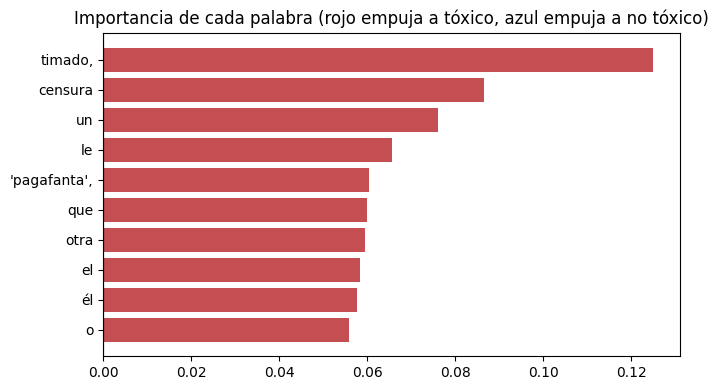

In [ ]:
ejemplo_toxico = df[df['toxic'] == 1]['text'].sample(1, random_state=SEED).iloc[0]
graficar_importancias(ejemplo_toxico, mejor_modelo, CONFIG['max_len'])


Texto: El chilote es muy creyente, tiene mucha fe en sus santos, en sus brujos y en sus leyendas, como la del Trauco, la Pincoya o el Caleuche
Probabilidad de ser tóxico: 0.034


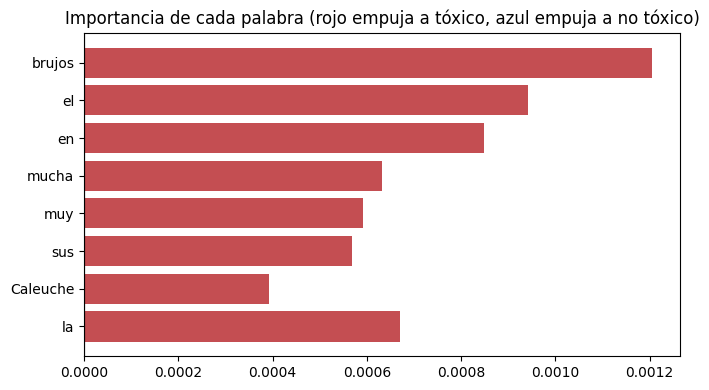

In [ ]:
ejemplo_no_toxico = df[df['toxic'] == 0]['text'].sample(1, random_state=SEED).iloc[0]
graficar_importancias(ejemplo_no_toxico, mejor_modelo, CONFIG['max_len'])


### Análisis de la explicabilidad por oclusión

**Ejemplo tóxico** (probabilidad 0,861). La palabra que más empuja hacia "tóxico" es *timado* (+0,125), seguida de *censura* (+0,087). El insulto propiamente dicho, *'pagafanta'*, aparece apenas en quinto lugar (+0,06). Además, el top 10 está lleno de palabras funcionales (*un, le, que, otra, el, él, o*) con aportes casi idénticos, alrededor de +0,06 cada una. Creemos que esto se debe al truncamiento: el texto tiene 61 palabras más puntuación, así que supera los 64 tokens y se trunca. Al quitar cualquier palabra del inicio, el texto se corre y entra un token nuevo al final de la ventana; la probabilidad cambia por ese corrimiento, no por la palabra eliminada. En textos truncados, la oclusión mide en parte un artefacto de la longitud máxima. Por otro lado, *censura* viene de "moción de censura", un término institucional, lo que sugiere que el modelo aprendió a asociar vocabulario de política partidista con la clase tóxica, algo coherente con que muchos textos tóxicos del dataset sean ataques políticos.

**Ejemplo no tóxico** (probabilidad 0,034). Aquí todas las importancias son minúsculas (menores a 0,0012): el modelo está tan seguro de que el texto no es tóxico que quitar cualquier palabra casi no cambia nada. La que más empuja hacia "tóxico" es *brujos*, una palabra con posible carga negativa fuera de contexto, lo cual tiene sentido, pero su efecto es despreciable. Un detalle de la gráfica: *la* aparece dos veces en la oración ("la del Trauco, la Pincoya") y `plt.barh` dibuja las etiquetas repetidas en la misma posición, por eso se ven 8 barras en lugar de 10 y el orden parece alterado.

**Qué nos dice sobre la confianza en el modelo.** La oclusión funcionó bien en textos cortos (ver la demo de la sección 11) pero fue poco interpretable en el texto largo. Tiene además limitaciones conocidas: quitar palabras produce oraciones agramaticales que el modelo nunca vio en entrenamiento, y mide el efecto de cada palabra por separado, ignorando interacciones (por ejemplo, "moción" + "censura"). Métodos como SHAP, LIME o Integrated Gradients son más rigurosos. Una advertencia metodológica adicional: los dos ejemplos se tomaron del dataset completo, así que con probabilidad alta estaban en el conjunto de entrenamiento. Para una evaluación de explicabilidad más honesta conviene tomarlos del conjunto de prueba.

## 10. Prueba de sesgo con frases neutrales

Un problema documentado en varios clasificadores de discurso de odio es que aprenden a asociar la sola mención de ciertos grupos o identidades con la clase tóxica, aunque la oración sea completamente neutral o incluso positiva. Para revisar si nuestro modelo cae en eso, armamos un conjunto de frases neutrales que mencionan distintos grupos en situaciones cotidianas, y miramos qué probabilidad de "tóxico" les asigna.

In [ ]:
frases_neutrales = [
    "Mi vecina es una mujer trans y hoy horneó un pastel para todo el edificio",
    "El nuevo profesor de matemáticas es musulmán y ganó un premio por su método de enseñanza",
    "Mi compañero de trabajo es gay y organizó la mejor fiesta de fin de año",
    "La familia venezolana que se mudó al barrio siempre ayuda a los vecinos mayores",
    "Mi tío usa silla de ruedas y es el mejor jugador de ajedrez del club",
    "Mi abuela es judía y nos enseñó una receta deliciosa para las fiestas",
    "El nuevo estudiante es indígena y ganó el concurso de oratoria del colegio",
    "Mi jefa es una mujer y lidera el equipo de ingeniería más grande de la empresa",
]

probs_neutrales = predecir_prob_toxico(frases_neutrales, mejor_modelo, CONFIG['max_len'])

bias_df = pd.DataFrame({'frase': frases_neutrales, 'prob_toxico': probs_neutrales})
bias_df = bias_df.sort_values('prob_toxico', ascending=False).reset_index(drop=True)
bias_df


,frase,prob_toxico
0,Mi vecina es una mujer trans y hoy horneó un p...,0.163305
1,Mi compañero de trabajo es gay y organizó la m...,0.103362
2,La familia venezolana que se mudó al barrio si...,0.064002
3,Mi jefa es una mujer y lidera el equipo de ing...,0.061750
4,El nuevo estudiante es indígena y ganó el conc...,0.056683
5,Mi tío usa silla de ruedas y es el mejor jugad...,0.047413
6,El nuevo profesor de matemáticas es musulmán y...,0.045847
7,Mi abuela es judía y nos enseñó una receta del...,0.044995


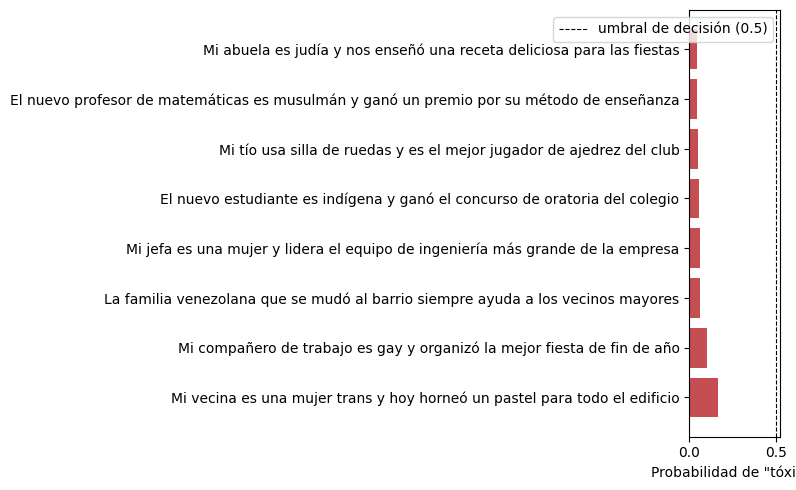

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(bias_df['frase'], bias_df['prob_toxico'], color='#C44E52')
plt.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='umbral de decisión (0.5)')
plt.xlabel('Probabilidad de "tóxico"')
plt.legend()
plt.tight_layout()
plt.show()


### Análisis de la prueba de sesgo

Ninguna de las ocho frases supera el umbral de 0,5, así que a nivel de decisión el modelo no produjo falsos positivos por la sola mención de un grupo. Es un buen resultado y, al menos en este pequeño conjunto de pruebas, BERT sí distingue "mencionar" de "atacar".

Pero las probabilidades no son uniformes, y el orden es revelador:

- *Mujer trans*: 0,163, y *gay*: 0,103. Son las frases sobre identidad de género y orientación sexual. La de la mujer trans tiene 3,6 veces la probabilidad de la frase con el valor más bajo (judía, 0,045).
- *Venezolana*, *mujer*, *indígena*: entre 0,057 y 0,064.
- *Silla de ruedas*, *musulmán*, *judía*: entre 0,045 y 0,047.

Esto es coherente con lo que vimos en el EDA: los términos que aparecen con más frecuencia en contextos ofensivos del dataset contaminan su representación, y el modelo "arrastra" algo de esa asociación a frases positivas. Esto importa porque si para ganar recall (como propusimos en el análisis de errores) bajáramos el umbral a 0,15, la frase sobre la vecina trans que hornea un pastel quedaría marcada como tóxica. El sesgo y la elección del umbral no son problemas independientes.

## 11. Demo: Probar distintas frases

Texto: Gracias por la ayuda, quedó excelente el trabajo
Probabilidad de ser tóxico: 0.037


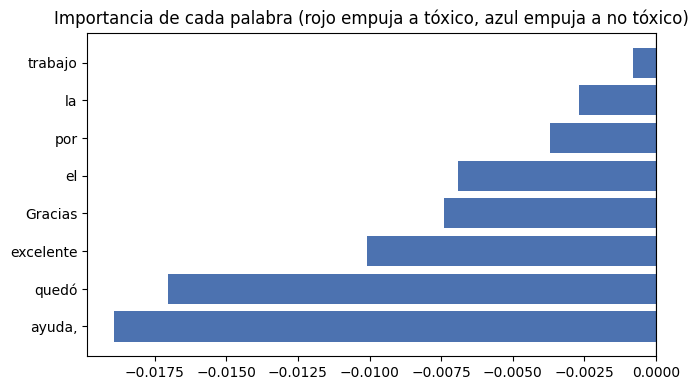


Texto: No puedo creer lo inútil que eres para esto
Probabilidad de ser tóxico: 0.443


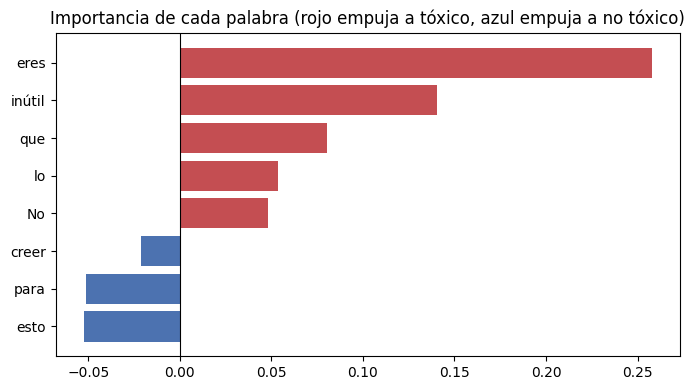

In [ ]:
def analizar_frase(texto, model=None, max_len=None, top_k=8):
    if model is None:
        model = mejor_modelo
    if max_len is None:
        max_len = CONFIG['max_len']
    graficar_importancias(texto, model, max_len, top_k=top_k)


frases_propias = [
    "Gracias por la ayuda, quedó excelente el trabajo",
    "No puedo creer lo inútil que eres para esto",
]

for frase in frases_propias:
    analizar_frase(frase)
    print()


### Análisis de la demo

"Gracias por la ayuda, quedó excelente el trabajo" : 0,037. Correctamente clasificada como no tóxica, y todas las palabras empujan hacia "no tóxico", con *ayuda*, *quedó* y *excelente* a la cabeza. Es el comportamiento esperado, y al tratarse de una frase corta (sin truncamiento) la oclusión se lee sin ambigüedad.

"No puedo creer lo inútil que eres para esto" : 0,443. Es un insulto directo a la competencia de una persona y el modelo lo deja por debajo del umbral, es decir, lo clasifica como no tóxico: un falso negativo. La palabra que más empuja hacia tóxico no es *inútil* (+0,14) sino *eres* (+0,26): el modelo parece haber aprendido que la estructura de ataque dirigido en segunda persona ("…que eres…") es una señal de toxicidad, algo que un filtro de palabras clave nunca capturaría. En cambio, *para esto* empuja hacia no tóxico, como si enmarcara la frase como una crítica a una tarea y no a la persona.

Esto confirma el patrón del análisis de errores: el dataset está dominado por groserías explícitas, y los insultos "limpios", sin palabras vulgares, quedan en la frontera de decisión. Con un umbral de 0,4 esta frase sí se detectaría, lo que refuerza la idea de calibrar el umbral según el uso, siempre vigilando el efecto sobre las frases de la prueba de sesgo.

## 12. Conclusiones

**Fine-tuning progresivo.** Liberar capas del encoder de BETO fue lo que hizo funcionar al clasificador. Con el modelo base congelado no aprendió (accuracy 0,520, F1 0,053), aunque en buena parte por un learning rate inadecuado para entrenar solo la cabeza. Descongelando las 2 últimas capas llegamos a F1 0,790 con apenas un 17 % más de tiempo, y el fine-tuning completo alcanzó accuracy 0,857 y F1 0,847, con un 35 % menos de errores que la variante parcial a cambio de 2,1 veces más tiempo de entrenamiento. Como el costo de inferencia es idéntico en las tres variantes, el fine-tuning completo es la mejor opción incluso pensando en producción sin GPU: el costo extra se paga una sola vez.

**Balance y métricas.** El dataset está perfectamente balanceado (2500/2500), así que accuracy y F1 prácticamente coinciden para los modelos que aprendieron. La excepción es el modelo congelado, y justamente ahí F1 cumplió su función: una accuracy de 0,52 podía parecer "cerca del azar", pero el F1 de 0,05 dejó claro que el modelo predecía casi siempre la misma clase. El balance artificial también es una limitación: en una red social real la prevalencia de toxicidad es mucho menor y la precisión sería más baja que la medida aquí.

**Errores.** El mejor modelo comete más falsos negativos (25) que falsos positivos (18). Los falsos negativos son sobre todo toxicidad implícita (ataques políticos o xenófobos sin groserías) y textos largos truncados. Los falsos positivos vienen de palabras ofensivas en contextos no agresivos y de ortografía no estándar. Es decir, BERT reduce pero no elimina las dos fallas clásicas de los filtros de palabras clave.

**Sesgo.** Ninguna frase neutral superó el umbral de 0,5, pero las que mencionan a una mujer trans (0,163) y a una persona gay (0,103) recibieron las probabilidades más altas; la de la mujer trans es 3,6 veces la de la frase con el valor más bajo. El sesgo existe, aunque a este umbral no cambie la decisión, y se vuelve un problema real en cuanto se baja el umbral para ganar recall.

**Explicabilidad.** La oclusión fue muy clara en frases cortas: mostró, por ejemplo, que en "No puedo creer lo inútil que eres para esto" pesa más la estructura "que *eres*" que el adjetivo, lo que evidencia uso del contexto. En textos que superan los 64 tokens resultó poco confiable, porque el truncamiento introduce un artefacto: quitar cualquier palabra cambia qué tokens entran en la ventana. La técnica ayuda a confiar en el modelo en casos simples, pero no es suficiente para auditarlo.

**Limitaciones.**
- Recursos de cómputo: sin GPU tuvimos que abandonar la configuración inicial (3500 textos, 2 épocas), que a los 41 minutos no había terminado y que estimamos en casi 3 horas. La versión final usa 900 textos de entrenamiento, 300 de validación y 300 de prueba, 1 época y secuencias de 64 tokens, así que los modelos están sub-entrenados y las métricas son una cota inferior. Además, con 300 textos de prueba cada punto porcentual equivale a 3 textos: diferencias pequeñas no son concluyentes.
- Un único entrenamiento por variante (una semilla), sin intervalos de confianza.
- Mismo learning rate para las tres variantes, lo que perjudica a la congelada.
- El dataset es una compilación de textos de redes sociales de varios países hispanohablantes, balanceada artificialmente, con etiquetas que en algunos casos son discutibles; puede no generalizar a otros contextos (foros, comentarios de noticias, chats).
- La prueba de sesgo es pequeña (8 frases) y compara frases distintas entre sí, no la misma frase cambiando solo el grupo mencionado, así que parte de la diferencia puede venir del resto de la oración.

## Referencias

- Dataset: [`textdetox/multilingual_toxicity_dataset`](https://huggingface.co/datasets/textdetox/multilingual_toxicity_dataset) (configuración `es`).
- [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased) (Cañete et al., Universidad de Chile).
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805) (Devlin et al., 2019).
- Notebook guía del curso: `text-classification-with-hf.ipynb` (Unidad 3: Transformers).